--- 3.1 PCA Experiment ---
Variance Ratio: 0.70 -> Original: 6 dims, PCA: 3 dims
Variance Ratio: 0.85 -> Original: 6 dims, PCA: 4 dims
Variance Ratio: 0.95 -> Original: 6 dims, PCA: 4 dims
Variance Ratio: 0.99 -> Original: 6 dims, PCA: 5 dims

--- 3.2 Clustering (GMM) ---


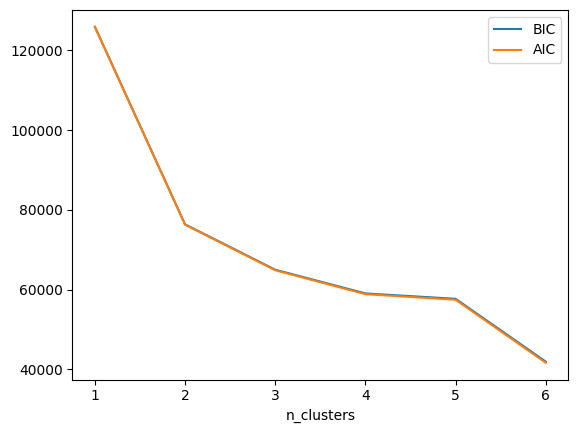


Improved RMSE with GMM Clusters: 1.0097


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor

# 1. データの読み込みと前処理（共通）
items = pd.read_csv('items.csv')
shops = pd.read_csv('shops.csv')
cats = pd.read_csv('item_categories.csv')
train = pd.read_csv('sales_train.csv')
test  = pd.read_csv('test.csv').set_index('ID')

# 外れ値・重複修正
train = train[(train.item_price < 100000) & (train.item_cnt_day < 1001)]
train.loc[train.shop_id == 0, 'shop_id'] = 57
test.loc[test.shop_id == 0, 'shop_id'] = 57

# エンコード
shops['city_code'] = LabelEncoder().fit_transform(shops['shop_name'].str.split(' ').map(lambda x: x[0]))
cats['type_code'] = LabelEncoder().fit_transform(cats['item_category_name'].str.split('-').map(lambda x: x[0].strip()))

# 2. 月間売上データの作成
matrix = []
for i in range(34):
    sales = train[train.date_block_num==i]
    if len(sales) > 0:
        matrix.append(np.array(list(product([i], sales.shop_id.unique(), sales.item_id.unique())), dtype='int16'))
matrix = pd.DataFrame(np.vstack(matrix), columns=['date_block_num','shop_id','item_id'])
group = train.groupby(['date_block_num','shop_id','item_id']).agg({'item_cnt_day': 'sum'})
group.columns = ['item_cnt_month']
matrix = pd.merge(matrix, group.reset_index(), on=['date_block_num','shop_id','item_id'], how='left').fillna(0)
matrix['item_cnt_month'] = matrix['item_cnt_month'].clip(0,20)

# 特徴量結合
matrix = pd.merge(matrix, shops[['shop_id','city_code']], on=['shop_id'], how='left')
matrix = pd.merge(matrix, items.drop(['item_name'], axis=1), on=['item_id'], how='left')
matrix = pd.merge(matrix, cats[['item_category_id','type_code']], on=['item_category_id'], how='left')

# 3. PCA（主成分分析）の演習
print("--- 3.1 PCA Experiment ---")
X_pca_target = matrix[matrix.date_block_num < 33].drop(['item_cnt_month'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_target)

# 寄与率を変えて次元数の変化を確認（課題回答）
for r in [0.70, 0.85, 0.95, 0.99]:
    pca = PCA(n_components=r)
    pca.fit(X_scaled)
    print(f"Variance Ratio: {r:.2f} -> Original: {X_scaled.shape[1]} dims, PCA: {pca.n_components_} dims")

# 4. クラスタリング（GMM）の演習
print("\n--- 3.2 Clustering (GMM) ---")
avg_price = train.groupby('item_id')['item_price'].mean().reset_index()
item_info = pd.merge(items, avg_price, on='item_id', how='left').fillna(0)
item_feat = StandardScaler().fit_transform(item_info[['item_price', 'item_category_id']])

# BIC/AICによる最適クラスタ数探索（グラフ表示）
n_components = np.arange(1, 7)
gmm_models = [GaussianMixture(n, random_state=42).fit(item_feat) for n in n_components]
plt.plot(n_components, [m.bic(item_feat) for m in gmm_models], label='BIC')
plt.plot(n_components, [m.aic(item_feat) for m in gmm_models], label='AIC')
plt.legend(); plt.xlabel('n_clusters'); plt.show()

# 最適なクラスタ（例として4）でラベル付け
gmm = GaussianMixture(n_components=4, random_state=42)
item_info['item_cluster'] = gmm.fit_predict(item_feat)

# 5. 精度改善の確認
matrix_imp = pd.merge(matrix, item_info[['item_id', 'item_cluster']], on='item_id', how='left')
X_train = matrix_imp[matrix_imp.date_block_num < 33].drop(['item_cnt_month'], axis=1)
Y_train = matrix_imp[matrix_imp.date_block_num < 33]['item_cnt_month']
X_valid = matrix_imp[matrix_imp.date_block_num == 33].drop(['item_cnt_month'], axis=1)
Y_valid = matrix_imp[matrix_imp.date_block_num == 33]['item_cnt_month']

model = XGBRegressor(n_estimators=100, max_depth=8, random_state=42)
model.fit(X_train, Y_train)
rmse_imp = np.sqrt(mean_squared_error(Y_valid, model.predict(X_valid)))
print(f'\nImproved RMSE with GMM Clusters: {rmse_imp:.4f}')